In [1]:
!pip install pandas numpy matplotlib seaborn scikit-learn openpyxl joblib

Defaulting to user installation because normal site-packages is not writeable


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score

import joblib

In [3]:
df = pd.read_excel("SuperStore Sales DataSet.xlsx")

df.head()

,Row ID+O6G3A1:R6,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Category,Sub-Category,Product Name,Sales,Quantity,Profit,Returns,Payment Mode,ind1,ind2
0,4918,CA-2019-160304,2019-01-01,2019-01-07,Standard Class,BM-11575,Brendan Murry,Corporate,United States,Gaithersburg,...,Furniture,Bookcases,"Bush Westfield Collection Bookcases, Medium Ch...",73.94,1,28.2668,NaN,Online,NaN,NaN
1,4919,CA-2019-160304,2019-01-02,2019-01-07,Standard Class,BM-11575,Brendan Murry,Corporate,United States,Gaithersburg,...,Furniture,Bookcases,"Bush Westfield Collection Bookcases, Medium Ch...",173.94,3,38.2668,NaN,Online,NaN,NaN
2,4920,CA-2019-160304,2019-01-02,2019-01-07,Standard Class,BM-11575,Brendan Murry,Corporate,United States,Gaithersburg,...,Technology,Phones,GE 30522EE2,231.98,2,67.2742,NaN,Cards,NaN,NaN
3,3074,CA-2019-125206,2019-01-03,2019-01-05,First Class,LR-16915,Lena Radford,Consumer,United States,Los Angeles,...,Office Supplies,Storage,Recycled Steel Personal File for Hanging File ...,114.46,2,28.6150,NaN,Online,NaN,NaN
4,8604,US-2019-116365,2019-01-03,2019-01-08,Standard Class,CA-12310,Christine Abelman,Corporate,United States,San Antonio,...,Technology,Accessories,Imation Clip USB flash drive - 8 GB,30.08,2,-5.2640,NaN,Online,NaN,NaN


In [4]:
# Convert date column (adjust name if needed)
df['Order Date'] = pd.to_datetime(df['Order Date'])

# Extract features
df['Year'] = df['Order Date'].dt.year
df['Month'] = df['Order Date'].dt.month
df['Day'] = df['Order Date'].dt.day

# Encode categorical columns
df['Category'] = df['Category'].astype('category').cat.codes
df['Region'] = df['Region'].astype('category').cat.codes

# Drop missing values
df = df.dropna()

In [5]:
X = df[['Year', 'Month', 'Day', 'Quantity', 'Category', 'Region']]
y = df['Sales']

In [19]:
import pandas as pd

df = pd.read_excel("SuperStore Sales DataSet.xlsx")

print("Original Shape:", df.shape)
df.head()

Original Shape: (5901, 23)


,Row ID+O6G3A1:R6,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Category,Sub-Category,Product Name,Sales,Quantity,Profit,Returns,Payment Mode,ind1,ind2
0,4918,CA-2019-160304,2019-01-01,2019-01-07,Standard Class,BM-11575,Brendan Murry,Corporate,United States,Gaithersburg,...,Furniture,Bookcases,"Bush Westfield Collection Bookcases, Medium Ch...",73.94,1,28.2668,NaN,Online,NaN,NaN
1,4919,CA-2019-160304,2019-01-02,2019-01-07,Standard Class,BM-11575,Brendan Murry,Corporate,United States,Gaithersburg,...,Furniture,Bookcases,"Bush Westfield Collection Bookcases, Medium Ch...",173.94,3,38.2668,NaN,Online,NaN,NaN
2,4920,CA-2019-160304,2019-01-02,2019-01-07,Standard Class,BM-11575,Brendan Murry,Corporate,United States,Gaithersburg,...,Technology,Phones,GE 30522EE2,231.98,2,67.2742,NaN,Cards,NaN,NaN
3,3074,CA-2019-125206,2019-01-03,2019-01-05,First Class,LR-16915,Lena Radford,Consumer,United States,Los Angeles,...,Office Supplies,Storage,Recycled Steel Personal File for Hanging File ...,114.46,2,28.6150,NaN,Online,NaN,NaN
4,8604,US-2019-116365,2019-01-03,2019-01-08,Standard Class,CA-12310,Christine Abelman,Corporate,United States,San Antonio,...,Technology,Accessories,Imation Clip USB flash drive - 8 GB,30.08,2,-5.2640,NaN,Online,NaN,NaN


In [20]:
df.columns = df.columns.str.strip()
print(df.columns)

Index(['Row ID+O6G3A1:R6', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode',
       'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State',
       'Region', 'Product ID', 'Category', 'Sub-Category', 'Product Name',
       'Sales', 'Quantity', 'Profit', 'Returns', 'Payment Mode', 'ind1',
       'ind2'],
      dtype='object')


In [21]:
print(df.columns.tolist())

['Row ID+O6G3A1:R6', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode', 'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State', 'Region', 'Product ID', 'Category', 'Sub-Category', 'Product Name', 'Sales', 'Quantity', 'Profit', 'Returns', 'Payment Mode', 'ind1', 'ind2']


In [22]:
df.rename(columns={
    'Order Date ': 'Order Date',
    'order date': 'Order Date'
}, inplace=True)

In [23]:
df['Order Date'] = pd.to_datetime(df['Order Date'], errors='coerce')

print(df['Order Date'].isnull().sum())

0


In [24]:
df = df.dropna(subset=['Order Date', 'Sales', 'Quantity'])

In [25]:
print("After cleaning:", df.shape)

After cleaning: (5901, 23)


In [26]:
df['Year'] = df['Order Date'].dt.year
df['Month'] = df['Order Date'].dt.month
df['Day'] = df['Order Date'].dt.day

In [27]:
df['Category'] = df['Category'].astype('category').cat.codes
df['Region'] = df['Region'].astype('category').cat.codes

In [28]:
print("Final Shape:", df.shape)

if df.shape[0] == 0:
    raise ValueError("❌ Dataset is STILL EMPTY — column names are wrong")

Final Shape: (5901, 26)


In [29]:
from sklearn.model_selection import train_test_split

X = df[['Year', 'Month', 'Day', 'Quantity', 'Category', 'Region']]
y = df['Sales']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("✅ SUCCESS — No Error")

✅ SUCCESS — No Error


In [31]:
rf_model = RandomForestRegressor(
    n_estimators=200,
    max_depth=10,
    random_state=42
)

rf_model.fit(X_train, y_train)

,n_estimators,200
,criterion,'squared_error'
,max_depth,10
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [32]:
y_pred = rf_model.predict(X_test)

print("MAE:", mean_absolute_error(y_test, y_pred))
print("R2 Score:", r2_score(y_test, y_pred))

MAE: 254.0998759986979
R2 Score: -0.005423559775536324


In [33]:
df['Predicted_Sales'] = rf_model.predict(X)

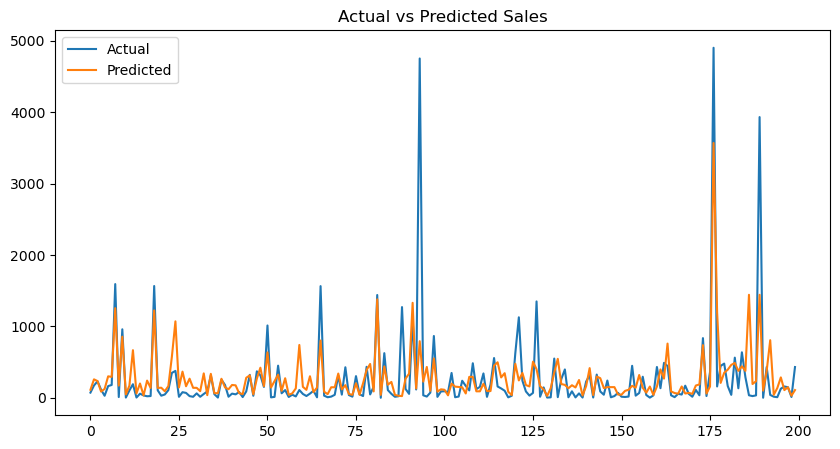

In [34]:
plt.figure(figsize=(10,5))
plt.plot(df['Sales'].values[:200], label='Actual')
plt.plot(df['Predicted_Sales'].values[:200], label='Predicted')
plt.legend()
plt.title("Actual vs Predicted Sales")
plt.show()

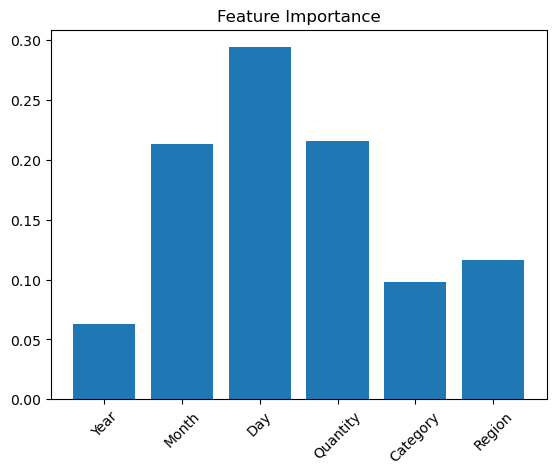

In [35]:
importance = rf_model.feature_importances_

plt.bar(X.columns, importance)
plt.title("Feature Importance")
plt.xticks(rotation=45)
plt.show()

In [36]:
df.to_csv("predicted_sales.csv", index=False)

In [37]:
joblib.dump(rf_model, "sales_model.pkl")

['sales_model.pkl']